# Lab 6.0 — Descriptive Statistics
**Course:** Linear Algebra and Statistics  
**Institute of Technology of Cambodia — Department of Applied Mathematics and Statistics**  
**Duration:** 1h

---

## Objectives
By the end of this lab, you will be able to:
- Compute **measures of central tendency** (mean, median, mode, midrange)
- Compute **measures of variation** (range, variance, standard deviation)
- Compute **measures of position** (z-scores, quartiles, IQR, outliers)
- Visualize data using **histograms**, **box plots**, and **frequency distributions**

---

## Setup — Run this cell first

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Plot style
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Part A — Guided Walkthrough (follow along)

We use the **record high temperatures (°F) for 50 U.S. states** from the lecture (Example 6).

In [4]:
# Record high temperatures for 50 U.S. states (°F)
temps = np.array([
    112, 100, 127, 120, 134, 118, 105, 110, 109, 112,
    110, 118, 117, 116, 118, 122, 114, 114, 105, 109,
    107, 112, 114, 115, 118, 117, 118, 122, 106, 110,
    116, 108, 110, 121, 113, 120, 119, 111, 104, 111,
    120, 113, 120, 117, 105, 110, 118, 112, 114, 114
])

print(f"Number of states (n): {len(temps)}")
print(f"Data:\n{temps}")

Number of states (n): 50
Data:
[112 100 127 120 134 118 105 110 109 112 110 118 117 116 118 122 114 114
 105 109 107 112 114 115 118 117 118 122 106 110 116 108 110 121 113 120
 119 111 104 111 120 113 120 117 105 110 118 112 114 114]


### A.1 — Measures of Central Tendency

In [5]:
mean_val   = np.mean(temps)
median_val = np.median(temps)
mode_val   = stats.mode(temps, keepdims=True).mode[0]
midrange   = (temps.min() + temps.max()) / 2

print("=== Measures of Central Tendency ===")
print(f"  Mean     : {mean_val:.2f} °F")
print(f"  Median   : {median_val:.2f} °F")
print(f"  Mode     : {mode_val} °F")
print(f"  Midrange : {midrange:.2f} °F")
print(f"  Min      : {temps.min()} °F   |   Max: {temps.max()} °F")

=== Measures of Central Tendency ===
  Mean     : 114.10 °F
  Median   : 114.00 °F
  Mode     : 118 °F
  Midrange : 117.00 °F
  Min      : 100 °F   |   Max: 134 °F


### A.2 — Measures of Variation

In [6]:
range_val  = temps.max() - temps.min()          # Range
var_pop    = np.var(temps, ddof=0)               # Population variance  σ²
std_pop    = np.std(temps, ddof=0)               # Population std dev   σ
var_samp   = np.var(temps, ddof=1)               # Sample variance      s²
std_samp   = np.std(temps, ddof=1)               # Sample std dev       s

print("=== Measures of Variation ===")
print(f"  Range              : {range_val}")
print(f"  Population Variance σ² : {var_pop:.4f}")
print(f"  Population Std Dev  σ  : {std_pop:.4f}")
print(f"  Sample Variance    s²  : {var_samp:.4f}")
print(f"  Sample Std Dev     s   : {std_samp:.4f}")

=== Measures of Variation ===
  Range              : 34
  Population Variance σ² : 38.0100
  Population Std Dev  σ  : 6.1652
  Sample Variance    s²  : 38.7857
  Sample Std Dev     s   : 6.2278


### A.3 — Measures of Position (Quartiles, IQR, Outliers)

In [7]:
Q1  = np.percentile(temps, 25)
Q2  = np.percentile(temps, 50)
Q3  = np.percentile(temps, 75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers    = temps[(temps < lower_fence) | (temps > upper_fence)]

print("=== Five-Number Summary ===")
print(f"  Min  : {temps.min()}")
print(f"  Q1   : {Q1}")
print(f"  Q2   : {Q2}  (Median)")
print(f"  Q3   : {Q3}")
print(f"  Max  : {temps.max()}")
print(f"\n  IQR  : {IQR}")
print(f"  Lower fence : {lower_fence}")
print(f"  Upper fence : {upper_fence}")
print(f"  Outliers    : {outliers if len(outliers) > 0 else 'None'}")

=== Five-Number Summary ===
  Min  : 100
  Q1   : 110.0
  Q2   : 114.0  (Median)
  Q3   : 118.0
  Max  : 134

  IQR  : 8.0
  Lower fence : 98.0
  Upper fence : 130.0
  Outliers    : [134]


### A.4 — Visualizations

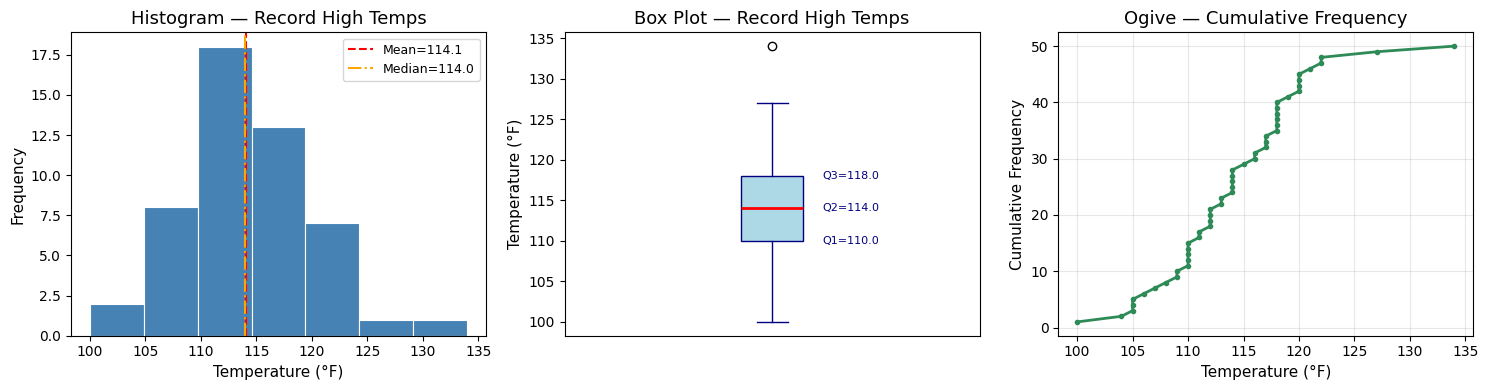

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Histogram ---
axes[0].hist(temps, bins=7, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
axes[0].axvline(median_val, color='orange', linestyle='-.',  linewidth=1.5, label=f'Median={median_val}')
axes[0].set_title('Histogram — Record High Temps')
axes[0].set_xlabel('Temperature (°F)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# --- Box Plot ---
bp = axes[1].boxplot(temps, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='navy'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='navy'),
                     capprops=dict(color='navy'),
                     flierprops=dict(marker='o', color='red', markersize=6))
axes[1].set_title('Box Plot — Record High Temps')
axes[1].set_ylabel('Temperature (°F)')
axes[1].set_xticks([])

# Annotate quartiles
for val, label in zip([Q1, Q2, Q3], ['Q1', 'Q2', 'Q3']):
    axes[1].text(1.12, val, f'{label}={val}', va='center', fontsize=8, color='navy')

# --- Frequency Polygon (Ogive-style) ---
sorted_temps = np.sort(temps)
cum_freq = np.arange(1, len(sorted_temps) + 1)
axes[2].plot(sorted_temps, cum_freq, color='seagreen', linewidth=2, marker='o', markersize=3)
axes[2].set_title('Ogive — Cumulative Frequency')
axes[2].set_xlabel('Temperature (°F)')
axes[2].set_ylabel('Cumulative Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### A.5 — Z-Scores

A **z-score** tells us how many standard deviations a value is from the mean:
$$z = \frac{X - \bar{x}}{s}$$

In [9]:
z_scores = (temps - mean_val) / std_samp

# Show the 5 most extreme z-scores
df_z = pd.DataFrame({'Temperature': temps, 'Z-Score': z_scores.round(3)})
df_z = df_z.reindex(df_z['Z-Score'].abs().sort_values(ascending=False).index)

print("Top 5 most extreme temperatures by z-score:")
print(df_z.head(5).to_string(index=False))

print(f"\nThe hottest state (134°F) has z = {(134 - mean_val)/std_samp:.3f}")
print(f"The coolest state (100°F) has z = {(100 - mean_val)/std_samp:.3f}")

Top 5 most extreme temperatures by z-score:
 Temperature  Z-Score
         134    3.195
         100   -2.264
         127    2.071
         104   -1.622
         105   -1.461

The hottest state (134°F) has z = 3.195
The coolest state (100°F) has z = -2.264


---
## Part B — Summary Table

All key statistics in one place:

In [10]:
summary = pd.DataFrame({
    'Statistic': [
        'n (count)', 'Mean (x̄)', 'Median', 'Mode', 'Midrange',
        'Min', 'Max', 'Range',
        'Pop. Variance (σ²)', 'Pop. Std Dev (σ)',
        'Sample Variance (s²)', 'Sample Std Dev (s)',
        'Q1', 'Q2', 'Q3', 'IQR'
    ],
    'Value': [
        len(temps), round(mean_val, 4), median_val, mode_val, midrange,
        temps.min(), temps.max(), range_val,
        round(var_pop, 4), round(std_pop, 4),
        round(var_samp, 4), round(std_samp, 4),
        Q1, Q2, Q3, IQR
    ]
})

print(summary.to_string(index=False))

           Statistic    Value
           n (count)  50.0000
           Mean (x̄) 114.1000
              Median 114.0000
                Mode 118.0000
            Midrange 117.0000
                 Min 100.0000
                 Max 134.0000
               Range  34.0000
  Pop. Variance (σ²)  38.0100
    Pop. Std Dev (σ)   6.1652
Sample Variance (s²)  38.7857
  Sample Std Dev (s)   6.2278
                  Q1 110.0000
                  Q2 114.0000
                  Q3 118.0000
                 IQR   8.0000


---
## ✏️ Exercise 1 — Monthly Phone Usage

Recall **Example 13** from the lecture. A random sample of 12 Verizon clients showed the following monthly minutes used:

```
90, 77, 94, 89, 119, 112, 91, 110, 92, 100, 113, 83
```

**Tasks:**
1. Compute the **mean, median, mode, and midrange**.
2. Compute the **sample standard deviation** `s`.
3. Compute the **quartiles Q1, Q2, Q3** and the **IQR**.
4. Check for **outliers** using the 1.5×IQR rule.
5. Draw a **box plot**.

> 💡 *Hint: copy-paste and adapt the code from Part A.*

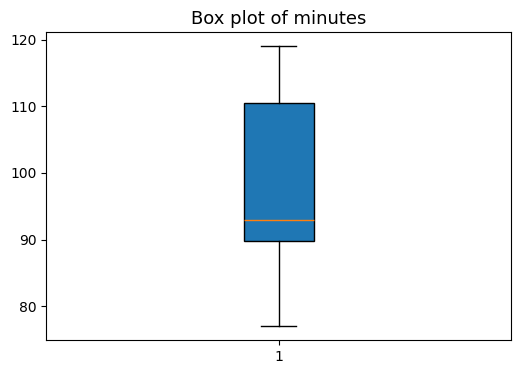

In [18]:

minutes = np.array([90, 77, 94, 89, 119, 112, 91, 110, 92, 100, 113, 83])

# 1. Central tendency
mean_m = np.mean(minutes)
median_m = np.median(minutes)
mode_m = stats.mode(minutes, keepdims=True).mode[0]
midrange_m = (minutes.min() + minutes.max()) / 2

# 2. Sample standard deviation
std_m = np.std(minutes, ddof=1)

# 3. Quartiles
Q1_m = np.percentile(minutes, 25)
Q2_m = np.percentile(minutes, 50)
Q3_m = np.percentile(minutes, 75)
IQR_m = Q3_m - Q1_m

# 4. Outliers
lower_m = Q1_m - 1.5 * IQR_m
upper_m = Q3_m + 1.5 * IQR_m
outliers_m = minutes[(minutes < lower_m) | (minutes > upper_m)]

# 5. Box plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(minutes, vert=True, patch_artist=True)
ax.set_title("Box plot of minutes")
plt.show()



**Expected answers (check your work):**
| Statistic | Value |
|-----------|-------|
| Mean | 97.5 min |
| Median | 95.5 min |
| Sample Std Dev | 13.07 min |
| Q1 | 89.75 |
| Q3 | 111.25 |
| IQR | 21.5 |
| Outliers | None |

---
## ✏️ Exercise 2 — Blood Type Frequency Distribution

Recall **Example 4** from the lecture. 25 army inductees were tested and their blood types recorded:

```
A B B AB O O O B AB B AB A O B B O A O A O O O AB B A
```

**Tasks:**
1. Build a **frequency table** (count and percentage for each blood type).
2. Draw a **bar chart** showing the frequency of each blood type.
3. Draw a **pie chart** showing the percentage of each blood type.
4. Which blood type is the **mode**?

> 💡 *Hint: use `pd.Series.value_counts()` and `plt.bar()` / `plt.pie()`.*

    Frequency  Percent
A           5       20
B           7       28
O           9       36
AB          4       16


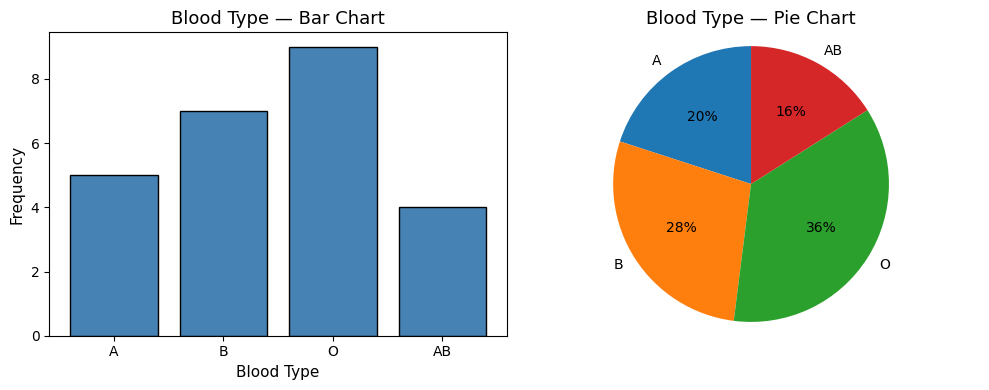

Mode (most common blood type): O


In [19]:
# --- Your code here ---
blood_types = ['A','B','B','AB','O','O','O','B','AB','B',
               'AB','A','O','B','B','O','A','O','A','O',
               'O','O','AB','B','A']

blood = pd.Series(blood_types)

# 1. Frequency table
order = ['A', 'B', 'O', 'AB']
freq_table = (
    blood.value_counts()
    .reindex(order)
    .fillna(0)
    .astype(int)
    .to_frame(name='Frequency')
)
freq_table['Percent'] = (freq_table['Frequency'] / len(blood) * 100).round(0).astype(int)

print(freq_table)

# 2. Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(freq_table.index, freq_table['Frequency'], color='steelblue', edgecolor='black')
axes[0].set_title('Blood Type — Bar Chart')
axes[0].set_xlabel('Blood Type')
axes[0].set_ylabel('Frequency')

# 3. Pie chart
axes[1].pie(
    freq_table['Frequency'],
    labels=freq_table.index,
    autopct='%1.0f%%',
    startangle=90
)
axes[1].set_title('Blood Type — Pie Chart')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

# 4. Mode
print(f"Mode (most common blood type): {blood.mode().iloc[0]}")

blood = pd.Series(blood_types)


**Expected answers (check your work):**
| Blood Type | Frequency | Percent |
|------------|-----------|--------|
| A  | 5 | 20% |
| B  | 7 | 28% |
| O  | 9 | 36% |
| AB | 4 | 16% |

**Mode = O** (most frequent)

---
## 🔍 Bonus — Chebyshev's Theorem (optional)

From the lecture: *at least* $1 - \frac{1}{k^2}$ of all values fall within $k$ standard deviations of the mean.

Using the **record high temperature** data, verify Chebyshev's theorem for k = 2 and k = 3.

In [21]:
for k in [2, 3]:
    chebyshev_bound = (1 - 1/k**2) * 100
    
    lower = mean_val - k * std_pop
    upper = mean_val + k * std_pop
    
    actual_count = np.sum((temps >= lower) & (temps <= upper))
    actual_pct   = actual_count / len(temps) * 100
    
    print(f"k = {k}:")
    print(f"  Chebyshev guarantee : at least {chebyshev_bound:.1f}%")
    print(f"  Interval            : [{lower:.2f}, {upper:.2f}]")
    print(f"  Actual % in interval: {actual_pct:.1f}%  ({actual_count}/{len(temps)} values)")
    print(f"  Guarantee satisfied : {'✅ YES' if actual_pct >= chebyshev_bound else '❌ NO'}\n")

k = 2:
  Chebyshev guarantee : at least 75.0%
  Interval            : [101.77, 126.43]
  Actual % in interval: 94.0%  (47/50 values)
  Guarantee satisfied : ✅ YES

k = 3:
  Chebyshev guarantee : at least 88.9%
  Interval            : [95.60, 132.60]
  Actual % in interval: 98.0%  (49/50 values)
  Guarantee satisfied : ✅ YES



---
## Summary of Key Formulas

| Measure | Formula | Python |
|---------|---------|--------|
| Sample Mean | $\bar{x} = \frac{\sum x}{n}$ | `np.mean(data)` |
| Median | Middle value after sorting | `np.median(data)` |
| Sample Variance | $s^2 = \frac{\sum(x-\bar{x})^2}{n-1}$ | `np.var(data, ddof=1)` |
| Sample Std Dev | $s = \sqrt{s^2}$ | `np.std(data, ddof=1)` |
| Z-score | $z = \frac{x - \bar{x}}{s}$ | `(x - mean) / std` |
| IQR | $Q_3 - Q_1$ | `Q3 - Q1` |
| Outlier fences | $Q_1 - 1.5 \cdot IQR$ and $Q_3 + 1.5 \cdot IQR$ | see code above |

---
*Lab 6.0 — Linear Algebra and Statistics, ITC*
